In [93]:
import pandas as pd 

df = pd.read_csv('../synthetic_data/synthetic_example.csv')

In [68]:
df

,Company,Project Name,Input Date,Status,Requester,Request Type,Priority,Request,Device,Browser,Page,Estimated Time (tokens),Real Time,ClientStrategicFit
0,Lee PLC,Little Redesign – Chocolate,26/10/2020,Complete,Peter Pugh,Design Issues,Urgent,Reporting a detail in Little Redesign – Chocol...,Desktop,Safari,https://www.littleredesign–chocolate.com,3,2,2.09
1,"Murphy, Wright and Jensen",Sign Landing – DarkOliveGreen,15/11/2024,Complete,Monica Edwards,New Item,Normal,"Monica Edwards, Murphy, Wright and Jensen – sm...",Mobile,Safari,https://www.signlanding–darkolivegreen.com,8,5,3.33
2,Wilson and Sons,Decide Website – MediumOrchid,20/11/2021,Complete,Christopher Durham,New Item,Urgent,"Christopher Durham, Wilson and Sons – small is...",Mobile,Firefox,https://www.decidewebsite–mediumorchid.com,8,6,3.77
3,"Sosa, Bell and King",Military Campaign – MediumSeaGreen,01/02/2020,Complete,Kenneth Hancock,Design Issues,High,"Hi all, reviewing Military Campaign – MediumSe...",Desktop,Chrome,https://www.militarycampaign–mediumseagreen.com,1,1,3.01
4,Monroe-Hinton,Everybody Landing – OrangeRed,18/03/2022,Complete,Tammy Steele,New Item,Urgent,Reporting a detail in Everybody Landing – Oran...,Mobile,Safari,https://www.everybodylanding–orangered.com,5,4,1.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Wilson and Sons,Rate Redesign – DarkSlateBlue,15/12/2021,Complete,Catherine Long,Copy Revision,Low,Noticed something odd in the contact form. Con...,Desktop,Edge,https://www.rateredesign–darkslateblue.com,1,1,3.77
9996,Miles LLC,Outside Platform – Red,23/10/2021,Complete,Bryan Frazier,Copy Revision,Low,Hi there! Bryan Frazier from Miles LLC here. T...,Desktop,Safari,https://www.outsideplatform–red.com,2,2,3.39
9997,Davis-Hernandez,Who Redesign – NavajoWhite,22/03/2024,Complete,Thomas Hoover,Requested Change,Normal,Reporting a detail in Who Redesign – NavajoWhi...,Desktop,Firefox,https://www.whoredesign–navajowhite.com,13,10,3.01
9998,Brown-Flores,Place Revamp – PaleGoldenRod,22/04/2024,Complete,Mark Woodard,New Item,Urgent,Hi! I’m looking at Place Revamp – PaleGoldenRo...,Desktop,Safari,https://www.placerevamp–palegoldenrod.com,8,6,3.77


In [69]:
df.describe()

,Estimated Time (tokens),Real Time,ClientStrategicFit
count,10000.000000,10000.000000,10000.000000
mean,4.750900,4.933400,2.958828
std,3.560073,4.044404,0.584683
min,1.000000,0.000000,1.740000
25%,2.000000,2.000000,2.440000
50%,3.000000,4.000000,3.010000
75%,8.000000,7.000000,3.390000
max,13.000000,32.000000,3.800000


In [94]:
df = pd.read_csv("../synthetic_data/synthetic_example.csv")

# EDA general del DataFrame
eda_summary = {
    "Dimensiones": df.shape,
    "Columnas": df.columns.tolist(),
    "Tipos de datos": df.dtypes,
    "Valores nulos por columna": df.isnull().sum(),
    "Valores únicos por columna": df.nunique(),
    "Estadísticas numéricas": df.describe(include=[float, int]),
    "Estadísticas categóricas": df.describe(include=[object])
}

eda_summary


{'Dimensiones': (10000, 14),
 'Columnas': ['Company',
  'Project Name',
  'Input Date',
  'Status',
  'Requester',
  'Request Type',
  'Priority',
  'Request',
  'Device',
  'Browser',
  'Page',
  'Estimated Time (tokens)',
  'Real Time',
  'ClientStrategicFit'],
 'Tipos de datos': Company                     object
 Project Name                object
 Input Date                  object
 Status                      object
 Requester                   object
 Request Type                object
 Priority                    object
 Request                     object
 Device                      object
 Browser                     object
 Page                        object
 Estimated Time (tokens)      int64
 Real Time                    int64
 ClientStrategicFit         float64
 dtype: object,
 'Valores nulos por columna': Company                    0
 Project Name               0
 Input Date                 0
 Status                     0
 Requester                  0
 Request Type      

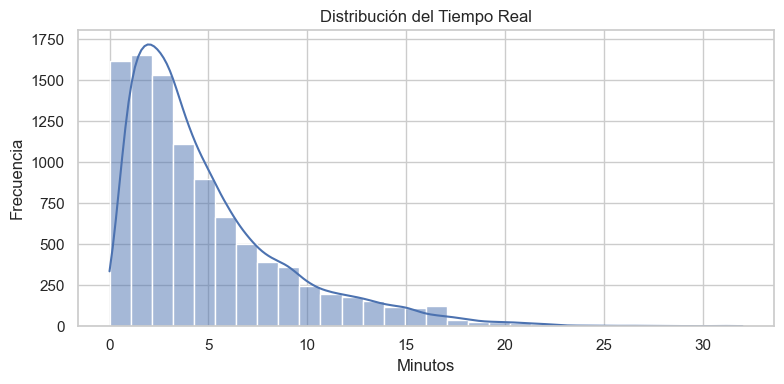

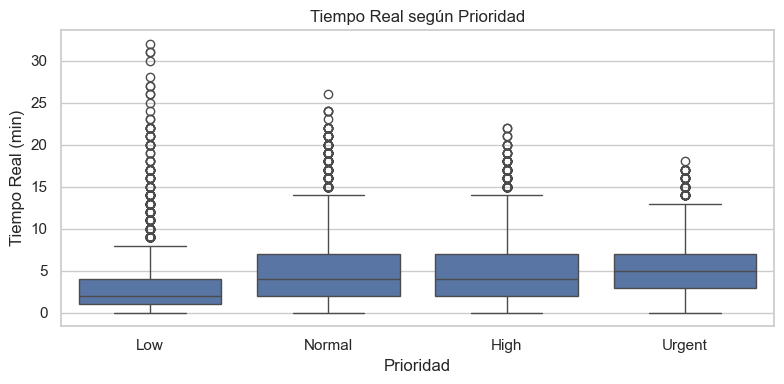

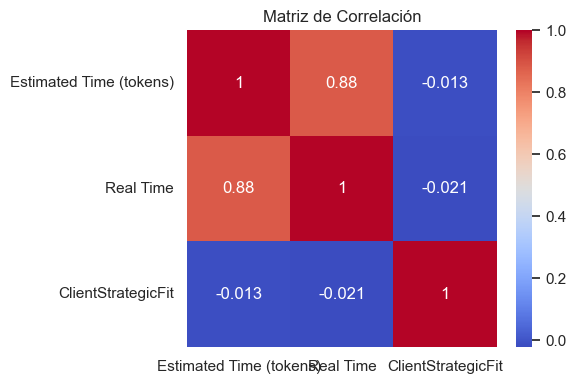

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set(style="whitegrid")

# Distribución del tiempo real
plt.figure(figsize=(8, 4))
sns.histplot(df["Real Time"], bins=30, kde=True)
plt.title("Distribución del Tiempo Real")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Boxplot del tiempo real por prioridad
plt.figure(figsize=(8, 4))
sns.boxplot(x="Priority", y="Real Time", data=df, order=["Low", "Normal", "High", "Urgent"])
plt.title("Tiempo Real según Prioridad")
plt.xlabel("Prioridad")
plt.ylabel("Tiempo Real (min)")
plt.tight_layout()
plt.show()

#  Matriz de correlación
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()


### Clasificación sin meter el modelo del tipo de tareas

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error, r2_score
# import numpy as np

# # Usaremos el texto de la columna 'Request' como input
# X_text = df['Request']
# y = df['Real Time']

# # Dividir en entrenamiento y prueba
# X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# # Vectorización TF-IDF
# vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
# X_train_vec = vectorizer.fit_transform(X_train_text)
# X_test_vec = vectorizer.transform(X_test_text)

# # Modelo: Random Forest Regressor
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train_vec, y_train)

# # Predicciones
# y_pred = model.predict(X_test_vec)

# # Evaluación
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# r2 = r2_score(y_test, y_pred)

# rmse, r2


(4.1897089559247345, -0.050779689381931004)

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import numpy as np
# import joblib

# # Usaremos el texto de la columna 'Request' como input
# X_text = df['Request']
# y = df['Real Time']

# # Dividir en entrenamiento y prueba
# X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# # Vectorización TF-IDF
# vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
# X_train_vec = vectorizer.fit_transform(X_train_text)
# X_test_vec = vectorizer.transform(X_test_text)

# # Modelo: Random Forest Regressor
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train_vec, y_train)

# # Predicciones
# y_pred = model.predict(X_test_vec)

# # Evaluación
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# mae = mean_absolute_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print(f"MAE:  {mae:.2f}")
# print(f"RMSE: {rmse:.2f}")
# print(f"R²:   {r2:.3f}")

#### Clasificación con el tipo de tareas 

In [2]:
# Reimportar datos ya que el entorno se ha reiniciado
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import joblib
import pandas as pd

# Cargar el archivo CSV original
file_path = '../synthetic_data/synthetic_example.csv'
df = pd.read_csv(file_path)

# Variables objetivo y predictoras
X_text = df['Request']
X_type = df['Request Type'] 
y = df['Real Time']

# Codificar el tipo de tarea como variable dummy
X_type_dummies = pd.get_dummies(X_type)

# Dividir en entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train_text, X_test_text, X_train_type, X_test_type, y_train, y_test = train_test_split(
    X_text, X_type_dummies, y, test_size=0.2, random_state=42
)

# Vectorización TF-IDF del texto
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

# Combinar texto vectorizado con variables categóricas
from scipy.sparse import hstack
X_train_combined = hstack([X_train_vec, X_train_type.values])
X_test_combined = hstack([X_test_vec, X_test_type.values])

# Entrenar el modelo
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_combined, y_train)

# Predicción y evaluación
y_pred = model.predict(X_test_combined)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

rmse, r2
# # Guardar modelo y vectorizador en un solo archivo
# model_package = {
#     "model": model,
#     "vectorizer": vectorizer
# }
# joblib.dump(model_package, "output_models_duracion/random_forest_model_duracion_TODO.pkl")

(4.047642135860394, 0.01927290047281449)

In [3]:
tfidf_features = vectorizer.get_feature_names_out()
type_features = X_type_dummies.columns.tolist()

all_feature_names = np.concatenate([tfidf_features, type_features])

importances = model.feature_importances_

feature_importances_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importances_df.head(20)


,Feature,Importance
102,New Item,0.121973
100,Copy Revision,0.045276
83,section,0.037184
17,consider,0.030776
4,area,0.020793
39,hi,0.018742
62,page,0.017732
58,new,0.017079
60,noticed,0.015976
74,reporting,0.013324


#### Clasificación con el modelo del tipo de tareas 

In [13]:
import pandas as pd
import joblib
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from scipy.sparse import hstack
import os

# Cargar datos
df = pd.read_csv("../synthetic_data/synthetic_example.csv")

# Cargar diccionario desde el archivo
with open("xgb_model_request_type.pkl", "rb") as f:
    model_dict = pickle.load(f)  # o joblib.load(f)

# Verifica qué contiene el diccionario
print("Claves del modelo cargado:", model_dict.keys())

# Extraer el modelo desde el diccionario
xgb_model = model_dict["model"]  # Asegúrate que esta clave existe
# Si necesitas el vectorizador también:
# type_vectorizer = model_dict["vectorizer"]

# Predecir tipo de tarea
predicted_types = xgb_model.predict(df["Request"])

# Convertir a one-hot encoding
predicted_df = pd.get_dummies(predicted_types)

# Vectorizar el texto para predecir duración
text_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_text_vec = text_vectorizer.fit_transform(df["Request"])

# Combinar texto vectorizado + tipo de tarea
X_combined = hstack([X_text_vec, predicted_df.values])

# Ajustar regresión para predecir duración
y = df["Real Time"]
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_combined, y)

# Predecir duración
df["Predicted Real Time"] = ridge_model.predict(X_combined)

# Crear el directorio si no existe
os.makedirs("output_models_duracion", exist_ok=True)

# Guardar el modelo con pickle
with open("output_models_duracion/random_forest_model_duracion_TODO.pkl", "wb") as f:
    pickle.dump(ridge_model, f)

# Mostrar resultado
print(df[["Request", "Predicted Real Time"]])

Claves del modelo cargado: dict_keys(['model', 'label_encoder'])
                                                Request  Predicted Real Time
0     Reporting a detail in Little Redesign – Chocol...             2.895391
1     Monica Edwards, Murphy, Wright and Jensen – sm...             6.152733
2     Christopher Durham, Wilson and Sons – small is...             6.651848
3     Hi all, reviewing Military Campaign – MediumSe...             3.529849
4     Reporting a detail in Everybody Landing – Oran...             5.495758
...                                                 ...                  ...
9995  Noticed something odd in the contact form. Con...             4.052042
9996  Hi there! Bryan Frazier from Miles LLC here. T...             4.293039
9997  Reporting a detail in Who Redesign – NavajoWhi...             5.613369
9998  Hi! I’m looking at Place Revamp – PaleGoldenRo...             7.576843
9999  Let’s improve in hero section. Consider widget...             6.470658

[10000 row

In [14]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calcular métricas
mae = mean_absolute_error(y, df["Predicted Real Time"])
r2 = r2_score(y, df["Predicted Real Time"])

# Mostrar resultados
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")


MAE: 2.51
R²: 0.26


In [ ]:
# rmse = np.sqrt(mean_squared_error(y, predicted_duration))
# r2 = r2_score(y, predicted_duration)

# print(f"RMSE: {rmse:.2f} tokens")
# print(f"R² Score: {r2:.3f}")

RMSE: 3.48 tokens
R² Score: 0.259


In [ ]:
# from sklearn.metrics import r2_score, mean_squared_error
# import numpy as np

# # Evaluar el modelo
# rmse = np.sqrt(mean_squared_error(y, predicted_duration))
# r2 = r2_score(y, predicted_duration)

# print(f"RMSE: {rmse:.2f} tokens")
# print(f"R² Score: {r2:.3f}")

RMSE: 3.48 tokens
R² Score: 0.259


In [ ]:
# from sklearn.metrics import mean_absolute_error

# # Calcular MAE
# mae = mean_absolute_error(y, predicted_duration)

# print(f"MAE: {mae:.2f} tokens")


MAE: 2.51 tokens


In [16]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.sparse import hstack
import joblib
import numpy as np

# 1. Cargar datos y modelo
df = pd.read_csv("../synthetic_data/synthetic_example.csv")
# Cargar diccionario desde el archivo
with open("xgb_model_request_type.pkl", "rb") as f:
    model_dict = pickle.load(f)
xgb_model = model_dict["model"]  # Asegúrate que esta clave existe

# 2. Predecir tipo de tarea (X)
predicted_types = xgb_model.predict(df["Request"])
df["Predicted Type"] = predicted_types  # guardar para análisis posterior

# 3. One-hot encoding del tipo de tarea
predicted_df = pd.get_dummies(predicted_types)

# 4. Vectorizar el texto
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_text_vec = vectorizer.fit_transform(df["Request"])

# 5. Combinar texto + tipo de tarea
X_combined = hstack([X_text_vec, predicted_df.values])

# 6. Ajustar modelo de regresión
y = df["Real Time"]
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_combined, y)

# 7. Predicción
predicted_duration = ridge_model.predict(X_combined)
df["Predicted Real Time"] = predicted_duration

# 8. Métricas globales
mae = mean_absolute_error(y, predicted_duration)
rmse = np.sqrt(mean_squared_error(y, predicted_duration))
r2 = r2_score(y, predicted_duration)

print(f"Global MAE:  {mae:.2f} horas")
print(f"Global RMSE: {rmse:.2f} horas")
print(f"Global R²:   {r2:.3f}")


# 9. Métricas por tipo de tarea (X)
print("\nMétricas por tipo de tarea:")
for task_type in df["Predicted Type"].unique():
    y_true = df[df["Predicted Type"] == task_type]["Real Time"]
    y_pred = df[df["Predicted Type"] == task_type]["Predicted Real Time"]

    mae_type = mean_absolute_error(y_true, y_pred)
    rmse_type = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_type = r2_score(y_true, y_pred)

    print(f"- {task_type}: MAE = {mae_type:.2f}, RMSE = {rmse_type:.2f}, R² = {r2_type:.3f}")

Global MAE:  2.51 horas
Global RMSE: 3.48 horas
Global R²:   0.259

Métricas por tipo de tarea:
- 1: MAE = 2.32, RMSE = 3.24, R² = 0.112
- 2: MAE = 3.12, RMSE = 3.92, R² = 0.136
- 0: MAE = 1.84, RMSE = 2.98, R² = 0.120
- 3: MAE = 2.71, RMSE = 3.67, R² = 0.135


In [ ]:
# # Reimportar librerías después del reinicio
# import pandas as pd

# # Cargar el archivo CSV actualizado
# df = pd.read_csv("../synthetic_data/synthetic_example.csv")

# # Mostrar los tipos únicos de tarea disponibles
# task_types = df["Request Type"].unique()
# task_types


array(['Design Issues', 'New Item', 'Copy Revision', 'Requested Change'],
      dtype=object)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Guardar resultados por tipo
results = []

# Iterar sobre cada tipo de tarea
for task_type in df["Request Type"].unique():
    df_subset = df[df["Request Type"] == task_type]
    X_text = df_subset["Request"]
    y = df_subset["Real Time"]

    # Separar en train/test
    X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

    # Vectorizar texto
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Entrenar modelo Random Forest Regressor
    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    model.fit(X_train_vec, y_train)

    # Predecir y evaluar
    y_pred = model.predict(X_test_vec)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Request Type": task_type,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R²": round(r2, 3)
    })

# Mostrar resultados
results_df = pd.DataFrame(results)
results_df


,Request Type,MAE,RMSE,R²
0,Design Issues,2.39,3.40,-0.036
1,New Item,3.38,4.19,-0.003
2,Copy Revision,1.76,2.89,-0.045
3,Requested Change,2.98,4.18,-0.030


In [ ]:
import pickle
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# Crear carpeta de salida
os.makedirs("output_models_duracion", exist_ok=True)

# Lista fija de los 4 tipos de tarea
task_types = ['Design Issues', 'New Item', 'Copy Revision', 'Requested Change']

# Entrenar y guardar 1 modelo por tipo
for task_type in task_types:
    df_subset = df[df["Request Type"] == task_type]
    X_text = df_subset["Request"]
    y = df_subset["Real Time"]

    # Separar en train/test
    X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

    # Vectorizar texto
    vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Entrenar modelo
    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    model.fit(X_train_vec, y_train)

    # Guardar todo en un solo diccionario
    model_package = {
        "model": model,
        "vectorizer": vectorizer,
        "metrics": {
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "R²": round(r2, 3)
        },
        "predictions": {
            "y_test": y_test.tolist(),
            "y_pred": y_pred.tolist()
        }
    }

    # Crear nombre seguro para archivo
    safe_name = task_type.replace(" ", "_").lower()
    filename = f"output_models_duracion/{safe_name}.pkl"

    # Guardar archivo
    with open(filename, "wb") as f:
        pickle.dump(model_package, f)

    print(f"Guardado: {filename}")

Guardado: output_models_duracion/design_issues.pkl
Guardado: output_models_duracion/new_item.pkl
Guardado: output_models_duracion/copy_revision.pkl
Guardado: output_models_duracion/requested_change.pkl


In [90]:
 # Predecir y evaluar
y_pred = model.predict(X_test_vec)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

r2, mae, 

(-0.029534972338085996, 2.981625059557086)